В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



Посилання на репозиторій: https://github.com/Striukova2910/ML_home_tasks/blob/main/process_bank_churn.py

In [66]:
import process_bank_churn
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from process_bank_churn import preprocess_new_data


**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

In [2]:
df = pd.read_csv('train.csv')

In [3]:
X_train, y_train, X_val, y_val, input_cols, scaler, encoder = process_bank_churn.preprocess_data(df)

In [4]:
# 1
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [5]:
# 2
#probabilities
train_probs = model.predict_proba(X_train)[:, 1]
val_probs = model.predict_proba(X_val)[:, 1]

#AUROC
train_roc = roc_auc_score(y_train, train_probs)
val_roc = roc_auc_score(y_val, val_probs)
print('Train ROC-AUC:', train_roc)
print('Validation ROC-AUC:', val_roc)

Train ROC-AUC: 1.0
Validation ROC-AUC: 0.7605357020371768


Видно, що модель перетренована, тренувальні результати 1, що є підозріло, а валідація це і підтвердила результатом 0.76.

In [6]:
# 3
model.tree_.max_depth

23

In [7]:
# 4
model_depth2 = DecisionTreeClassifier(max_depth=2, random_state=42)
model_depth2.fit(X_train, y_train)
print("DEPTH 2 train: ", model_depth2.score(X_train, y_train))
print("DEPTH 2 validation: ", model_depth2.score(X_val, y_val))

DEPTH 2 train:  0.86575
DEPTH 2 validation:  0.861


In [8]:
# 5
importance_df = pd.DataFrame(
    {
        'feature': X_train.columns,
        'importance': model_depth2.feature_importances_
    }).sort_values('importance', ascending=False
)

In [9]:
importance_df.head(10)

,feature,importance
3,Age,0.714962
6,NumOfProducts,0.285038
0,id,0.000000
2,CreditScore,0.000000
1,CustomerId,0.000000
4,Tenure,0.000000
5,Balance,0.000000
7,HasCrCard,0.000000
8,IsActiveMember,0.000000
9,EstimatedSalary,0.000000


Найважливішими ознаками є Age та NumofProducts.

**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

In [43]:
# 1
model_max_depth4 = DecisionTreeClassifier(max_depth=4, random_state=42)
model_max_depth4.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [44]:
train_auc = roc_auc_score(y_train, model_max_depth4.predict_proba(X_train)[:, 1])
val_auc = roc_auc_score(y_val, model_max_depth4.predict_proba(X_val)[:, 1])

In [45]:
print("DEPTH 4 train AUC: ", train_auc)
print("DEPTH 4 validation AUC: ", val_auc)

DEPTH 4 train AUC:  0.911281487788079
DEPTH 4 validation AUC:  0.9112638041017903


In [46]:
# 2
model_max_depth10 = DecisionTreeClassifier(max_depth=10, random_state=42)
model_max_depth10.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [47]:
train_auc10 = roc_auc_score(y_train, model_max_depth10.predict_proba(X_train)[:, 1])
val_auc_10 = roc_auc_score(y_val, model_max_depth10.predict_proba(X_val)[:, 1])

In [54]:
print("DEPTH 10 train AUC: ", train_auc10)
print("DEPTH 10 validation AUC: ", val_auc_10)

DEPTH 10 train AUC:  0.9712268765941083
DEPTH 10 validation AUC:  0.8417542355442761


In [55]:
# 3
model_max_depth14 = DecisionTreeClassifier(max_depth=14, random_state=42)
model_max_depth14.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=14, random_state=42)

In [56]:
train_auc_14 = roc_auc_score(y_train, model_max_depth14.predict_proba(X_train)[:, 1])
val_auc_14 = roc_auc_score(y_val, model_max_depth4.predict_proba(X_val)[:, 1])

In [57]:
print("DEPTH 14 train AUC: ", train_auc_14)
print("DEPTH 14 validation AUC: ", val_auc_14)

DEPTH 14 train AUC:  0.9971093118456584
DEPTH 14 validation AUC:  0.9112638041017903


In [58]:
# 4
model_max_depth6 = DecisionTreeClassifier(max_depth=6, random_state=42)
model_max_depth6.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, random_state=42)

In [59]:
train_auc6 = roc_auc_score(y_train, model_max_depth6.predict_proba(X_train)[:, 1])
val_auc6 = roc_auc_score(y_val, model_max_depth6.predict_proba(X_val)[:, 1])

In [60]:
print("DEPTH 6 train AUC: ", train_auc6)
print("DEPTH 6 validation AUC: ", val_auc6)

DEPTH 6 train AUC:  0.9344140622389211
DEPTH 6 validation AUC:  0.9193871321764181


In [22]:
# max_leaf_nodes 1
model_max_leaf = DecisionTreeClassifier(max_leaf_nodes=10, random_state=42)
model_max_leaf.fit(X_train, y_train)

DecisionTreeClassifier(max_leaf_nodes=10, random_state=42)

In [23]:
train_auc_leaf10 = roc_auc_score(y_train, model_max_leaf.predict_proba(X_train)[:, 1])
val_auc_leaf10 = roc_auc_score(y_val, model_max_leaf.predict_proba(X_val)[:, 1])

In [24]:
print("Max_leaf_nodes 10 train: ", train_auc_leaf10)
print('Max_leaf_nodes 10 validation: ', val_auc_leaf10)

Max_leaf_nodes 10 train:  0.9014754782174744
Max_leaf_nodes 10 validation:  0.9002184649152891


In [25]:
# 2
model_max_leaf7 = DecisionTreeClassifier(max_leaf_nodes=7, random_state=42)
model_max_leaf7.fit(X_train, y_train)

DecisionTreeClassifier(max_leaf_nodes=7, random_state=42)

In [26]:
train_auc_leaf7 = roc_auc_score(y_train, model_max_leaf7.predict_proba(X_train)[:, 1])
val_auc_leaf7 = roc_auc_score(y_val, model_max_leaf7.predict_proba(X_val)[:, 1])

In [27]:
print("Max_leaf_nodes 7 train: ", train_auc_leaf7)
print('Max_leaf_nodes 7 validation: ', val_auc_leaf7)

Max_leaf_nodes 7 train:  0.8942216698808036
Max_leaf_nodes 7 validation:  0.887284107277591


In [28]:
# 3
model_max_leaf12 = DecisionTreeClassifier(max_leaf_nodes=12, random_state=42)
model_max_leaf12.fit(X_train, y_train)

DecisionTreeClassifier(max_leaf_nodes=12, random_state=42)

In [34]:
train_auc_leaf12 = roc_auc_score(y_train, model_max_leaf12.predict_proba(X_train)[:, 1])
val_auc_leaf12 = roc_auc_score(y_val, model_max_leaf12.predict_proba(X_val)[:, 1])

In [35]:
print("Max_leaf_nodes 12 train: ", train_auc_leaf12)
print('Max_leaf_nodes 12 validation: ', val_auc_leaf12)

Max_leaf_nodes 12 train:  0.9065075818842296
Max_leaf_nodes 12 validation:  0.9069222854791139


**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

In [36]:
def max_depth_exp(md):
    model_exp = DecisionTreeClassifier(max_depth=md, random_state=42)
    model_exp.fit(X_train, y_train)
    train_probs = model_exp.predict_proba(X_train)[:, 1]
    val_probs = model_exp.predict_proba(X_val)[:, 1]
    train_auc = roc_auc_score(y_train, train_probs)
    val_auc = roc_auc_score(y_val, val_probs)
    return {'Max Depth': md, 'Train-AUC': train_auc, 'Validation-AUC': val_auc, 'difference':train_auc - val_auc}

In [37]:
depth_df = pd.DataFrame([max_depth_exp(md) for md in range(1, 21)])
depth_df.sort_values('Validation-AUC', ascending=False).head(10)

,Max Depth,Train-AUC,Validation-AUC,difference
4,5,0.925766,0.923464,0.002302
5,6,0.934414,0.919387,0.015027
6,7,0.941928,0.917229,0.024699
3,4,0.911281,0.911264,0.000018
7,8,0.950111,0.908509,0.041601
2,3,0.897184,0.891146,0.006038
8,9,0.960972,0.873977,0.086995
1,2,0.842908,0.846496,-0.003589
9,10,0.971227,0.841754,0.129473
10,11,0.980241,0.825419,0.154823


In [38]:
depth_df.style.background_gradient(subset = ['Validation-AUC'], cmap='viridis')

,Max Depth,Train-AUC,Validation-AUC,difference
0,1,0.744727,0.734865,0.009862
1,2,0.842908,0.846496,-0.003589
2,3,0.897184,0.891146,0.006038
3,4,0.911281,0.911264,0.000018
4,5,0.925766,0.923464,0.002302
5,6,0.934414,0.919387,0.015027
6,7,0.941928,0.917229,0.024699
7,8,0.950111,0.908509,0.041601
8,9,0.960972,0.873977,0.086995
9,10,0.971227,0.841754,0.129473


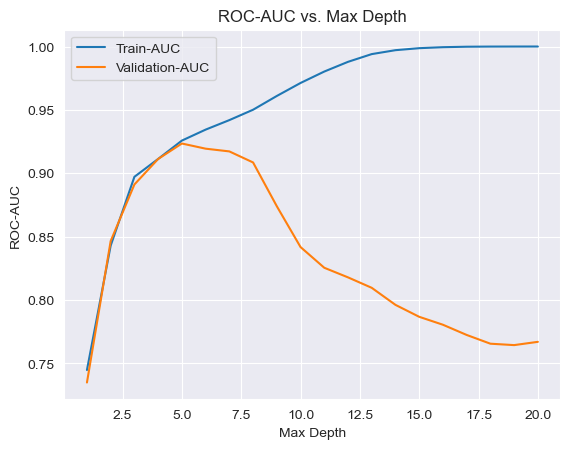

In [39]:
plt.figure()
plt.plot(depth_df['Max Depth'], depth_df['Train-AUC'])
plt.plot(depth_df['Max Depth'], depth_df['Validation-AUC'])
plt.xlabel('Max Depth')
plt.ylabel('ROC-AUC')
plt.title('ROC-AUC vs. Max Depth')
plt.grid(True)
plt.legend(['Train-AUC', 'Validation-AUC'])
plt.show()

**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [85]:
# 1
model_max_depth_5 = DecisionTreeClassifier(max_depth=5, random_state=42)
model_max_depth_5.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [86]:
train_auc_5 = roc_auc_score(y_train, model_max_depth_5.predict_proba(X_train)[:, 1])
val_auc_5 = roc_auc_score(y_val, model_max_depth_5.predict_proba(X_val)[:, 1])

In [87]:
print("DEPTH 5 train AUC: ", train_auc_5)
print("DEPTH 5 validation AUC: ", val_auc_5)

DEPTH 5 train AUC:  0.9257663544386708
DEPTH 5 validation AUC:  0.9234638864119625


In [93]:
train_df = pd.read_csv('train.csv')
X_train, y_train, X_val, y_val, input_cols, scaler, encoder = process_bank_churn.preprocess_data(train_df)

In [95]:
model_md_5 = DecisionTreeClassifier(max_depth=5, random_state=42)
model_md_5.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [96]:
# 2
test = pd.read_csv('test.csv')

In [99]:
# 3
test_processed = process_bank_churn.preprocess_new_data(test, input_cols, encoder, scaler = scaler)


In [101]:
# 4
test_pred = model_md_5.predict_proba(test_processed)[:, 1]

In [102]:
# 5
submission = pd.read_csv('sample_submission.csv')
submission['Exited'] = test_pred
submission.to_csv('submission.csv', index=False)

In [103]:
submission.head()

,id,Exited
0,15000,0.237911
1,15001,0.027613
2,15002,0.027613
3,15003,0.761702
4,15004,0.027613


![Kaggle Score](kaggle_score.png)